In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT=>Temperature
#V=>Vaccum
#AP=>Pressure
#RH=>Humidity

#PE=> Produced Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [14]:
# define our ANN Module
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model= nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            #2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            #output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [15]:
import torch.optim as optim

model=ANN()

#Loss, Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [16]:
#Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = feature of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward propahation predicted output for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss+=loss.item() # loss is a tensor so convert it into a python float value
        
    epoch_train_loss =running_loss / len(train_loader)        
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss =running_val_loss / len(test_loader)        
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

epoch 1/100 ==> train loss = 205283.32955729167 & val loss = 201903.1875
epoch 2/100 ==> train loss = 190311.56725260417 & val loss = 171348.421875
epoch 3/100 ==> train loss = 139560.27740885416 & val loss = 102988.109375
epoch 4/100 ==> train loss = 67773.89268391927 & val loss = 38327.55078125
epoch 5/100 ==> train loss = 22590.99165649414 & val loss = 13266.8779296875
epoch 6/100 ==> train loss = 9699.705106608073 & val loss = 7995.03173828125
epoch 7/100 ==> train loss = 6744.206441243489 & val loss = 6132.0
epoch 8/100 ==> train loss = 5233.233592732748 & val loss = 4800.0947265625
epoch 9/100 ==> train loss = 4067.1560475667316 & val loss = 3739.906005859375
epoch 10/100 ==> train loss = 3113.2948542277018 & val loss = 2875.52490234375
epoch 11/100 ==> train loss = 2346.442335510254 & val loss = 2172.02099609375
epoch 12/100 ==> train loss = 1733.383563232422 & val loss = 1611.290771484375
epoch 13/100 ==> train loss = 1262.433134841919 & val loss = 1174.9278564453125
epoch 14/1

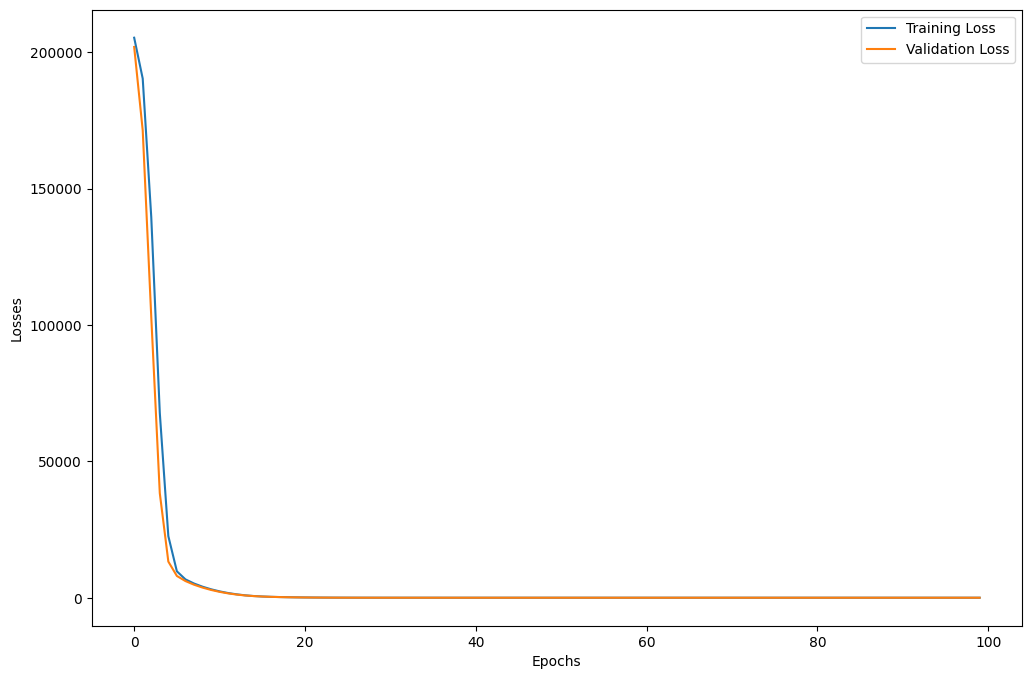

In [17]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12, 8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [18]:
# Loading the best model 
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [19]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Test MSE:", test_mse_loss.item())

Training MSE: 20.331491470336914
Test MSE: 18.524499893188477


In [20]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_preds))

r^2 score =  0.935261652931211


In [21]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.118347,433.27
1,436.471710,438.16
2,461.620575,458.42
3,476.489319,480.82
4,435.362946,441.41
...,...,...
1909,451.171082,456.70
1910,431.323090,438.04
1911,467.595612,467.80
1912,430.697113,437.14
